# 函数进阶

- 变量作用范围。全局与局部变量
    - 全局变量：在函数之外定义的变量，在整个文件中都可以使用（包括函数内），通常定义在文件顶部。
    - 局部变量： 只能在函数内部使用，外部无法访问。函数执行完毕后会自动销毁其内部局部变量。  

在下面这例子中，函数中的 ```num``` 会遮蔽（shadow）全局变量 ```num```。在函数执行期间，函数内部访问 ```num``` 时，访问的是局部变量，而不是全局变量。  
它们属于不同的作用域，因此是两个不同的变量，互不影响。


In [6]:
num = 100

def circle_area(r: float) -> float:
    """
    根据圆的半径计算面积
    :parm r: 圆的半径
    :return: 圆的面积
    """

    pi = 3.14
    area = r**2 * pi
    num = 1000
    print("局部变量 num =", num)
    return area

circle_area(5)
print("全局变量 num =", num)
# print("pi =", pi)

在函数中 num = 1000
在外部 num = 100


- global 关键字告诉解释器：在函数中要使用全局变量，而不是一个同名的局部变量。从而能够修改全局变量的值
- 注意：
    - 尽量避免在函数中使用全局变量，会使代码难以维护
    - 考虑使用函数参数和返回值来在函数中传递数据，而不是**全局变量**
    - global 主要用在程序的状态、配置和计数器等场景

In [7]:
num1 = 1
def fun1() -> None:
    global num1
    num1 = 100
    print(num1)

fun1()
print(num1)

100
100


- 位置传参，对输入函数参数的位置有要求
- 关键字传参，对参数位置无要求。以“键值对”的形式传递参数
注意：如果两个混用，则**关键字参数**必须在**位置参数**之后

### 默认参数
- 默认参数在定义函数时，为函数中的变量提供默认值。调用函数时，可以不传递有默认值的参数

In [ ]:
def reg_stu(name, age, gender, city='北京'):
    """_summary_

    Args:
        name (_type_): _description_
        age (_type_): _description_
        gender (_type_): _description_
        city (str, optional): _description_. Defaults to '北京'.
    """
    print(f"{name}, {age}, {gender}, {city}")

### 不定长参数
- 位置传递(*args)  
    - 传递的所有匹配的位置参数都会被args变量收集，这些参数会合并封装为一个元组  
    位置参数指的是输入参数的时候按照函数自身定义的参数顺序，不写键名，直接把参数按参数定义位置顺序进行输入。  
args是元组类型（不会封装关键字参数）  
元组（Tuple）是一种有序、不可修改的数据类型，常用于将多个相关的数据组合在一起，尤其适合作为函数返回多个值时的返回类型。  
    - args只是约定俗成的变量名，并不是关键字，这里可以使用任何合法的变量名，如 ```*data```

In [10]:
def calc_data(*args):
    min_data = min(args)
    max_data = max(args)

    return min_data, max_data

In [11]:
data = calc_data(10, 20, 30, 40, 50, 60, 70, 90)
print(data)

(10, 90)


- 关键字传参**(**kwargs)** keyword args
    - 参数以“键=值”形式传递的关键字参数，键值对都会被kwargs接收，合并封装为一个**字典类型**
    - 同样，kwargs也只是约定俗成的变量名，可以使用其他进行替代，如```**options```

In [15]:
def calc_data_round(*args, **kwargs):
    min_data = min(args)
    max_data = max(args)
    avg_data = sum(args) / len(args)

    if kwargs.get('round'):
        avg_data = round(avg_data, kwargs.get('round'))
    print(kwargs)

    return min_data, max_data, avg_data


data = calc_data_round(10, 20, 30, 40, 50, 65, 70, round=2, count=0)
print(data)

{'round': 2, 'count': 0}
(10, 70, 40.71)


### 函数的参数类型
- 普通参数：基本变量类型
- 特殊参数：函数

In [18]:
def add(x, y):
    return x+y

def subtract(x,y):
    return x-y

def calc(x, y, oper):
    return oper(x, y) # 函数调用的语法，函数作为参数传入，在返回处进行调用

In [17]:
result = calc(10, 3, add)
print(result)

13


## 匿名函数
- 指的是没有名称的函数，需要通过lambda表达式来声明函数，可以简化**简单函数**的编写（单行表达式）  
```lambda 参数列表 : 函数体```  
自带return操作
- 函数逻辑比较简单且只在一个地方使用时，可以考虑使用匿名函数。通常作为高阶函数的参数使用
- 匿名函数可以返回或者不返回结构，表达式的运行结果就是要返回的结果

In [19]:
out_line = lambda : print('----------------------')

add = lambda x, y : x + y

out_line()
print(add(12, 14))

----------------------
26


题目：计算学生总成绩

有一个学生成绩列表，每个学生的数据如下：

students = [
    ("张三", 85, 92),
    ("李四", 78, 88),
    ("王五", 90, 95),
    ("赵六", 80, 76)
]

每个元组依次表示：

(姓名, 数学成绩, 英语成绩)

请使用 匿名函数（lambda） 完成下面任务。

要求
使用 sorted() 按照**总成绩（数学 + 英语）**从高到低排序。
输出排序后的结果。

期望输出：

('王五', 90, 95)
('张三', 85, 92)
('李四', 78, 88)
('赵六', 80, 76)

In [21]:
students = [
    ("张三", 85, 92),
    ("李四", 78, 88),
    ("王五", 90, 95),
    ("赵六", 80, 76)
]

sorted(students, key=lambda x : x[1]+x[2], reverse=True)

[('王五', 90, 95), ('张三', 85, 92), ('李四', 78, 88), ('赵六', 80, 76)]

按照每一个元素字符个数，从小到大排序  
解：这里的key中的data是data_list中的每一个字符串，key是一个**能够计算每个字符串的长度大小的函数**  
    相当于逐个字符串算长度后作为排序标准

In [24]:
data_list = ["C++", "C", "Python", "Jack", "PHP", "Java", "Go", "JavaScript", "Rust"]

a = sorted(data_list, key=lambda data : len(data))
print(a)

['C', 'Go', 'C++', 'PHP', 'Jack', 'Java', 'Rust', 'Python', 'JavaScript']


上面的lambda表达式等价于下面的函数定义

In [25]:
def get_lenth(word: str) -> int:
    return len(word)

res = sorted(data_list, key=get_lenth)
print(res)

['C', 'Go', 'C++', 'PHP', 'Jack', 'Java', 'Rust', 'Python', 'JavaScript']


- 定义一个函数，根据输入的数字，计算该数的阶乘

In [ ]:
def factorial(num: int) -> int:
    res = 1
    for i in range(1, num+1):
        res *= i
    return res

# 递归方法
def factorial_new(num: int) -> int:
    if num == 1:
        return 1
    return num * factorial_new(num-1)

print(factorial(1))
print(factorial_new(5))

1
120


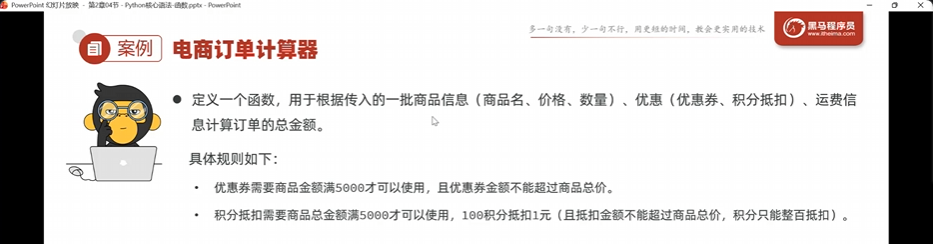

In [37]:

def get_total_cost(cupon_value: int, points: int, freight: float, *product_info) -> float:
    total_cost = sum([product[1] * product[2] for product in product_info])
    if total_cost >= 5000:
        if cupon_value < total_cost:
            total_cost -= cupon_value
        if points :
            total_cost -= points // 100
        
        return max(total_cost + freight, 0)
    else:
        return max(total_cost + freight, 0)


products = ("鼠标", 348, 2), ("键盘", 148, 3), ("iphone", 5148, 2)
res = get_total_cost(10, 4000, 9.9, *products)
print(res)

    
    

11395.9


In [38]:
def test(*args):
    print(args)
    print("参数个数：", len(args))
    print("-" * 30)


products = (
    ("鼠标", 348, 2),
    ("键盘", 148, 3),
    ("iphone", 5148, 2)
)

test(products)

test(*products)

((('鼠标', 348, 2), ('键盘', 148, 3), ('iphone', 5148, 2)),)
参数个数： 1
------------------------------
(('鼠标', 348, 2), ('键盘', 148, 3), ('iphone', 5148, 2))
参数个数： 3
------------------------------
